In [1]:
%pip install --upgrade 'qiskit[visualization]>=2.5.0' qiskit-aer qiskit-ibm-runtime matplotlib

Saved figure: fig2_rebuild.png

Number of qubits           : 10
Trainable parameters in U_Q: 40 (4 x n)
Trainable parameters in U_K: 40 (4 x n)
Total quantum parameters   : 80 (the paper says 80)

Query vector length: 30 (3 x n = 30)
First 6 values of Q (Aer): [ 0.2275 -0.0277  0.016  -0.0698  0.0466  0.0324]
Max difference Aer vs Statevector: 8.77e-15
Scaled dot product Q.K / sqrt(30) = 0.0028

Shot-based measurement vs exact Aer (RMSE over the 30 values):
  shots =    100   RMSE = 0.0979 +- 0.0116
  shots =   1000   RMSE = 0.0320 +- 0.0063
  shots =  10000   RMSE = 0.0096 +- 0.0004
  shots = 100000   RMSE = 0.0033 +- 0.0001
Saved figure: aer_shot_error.png


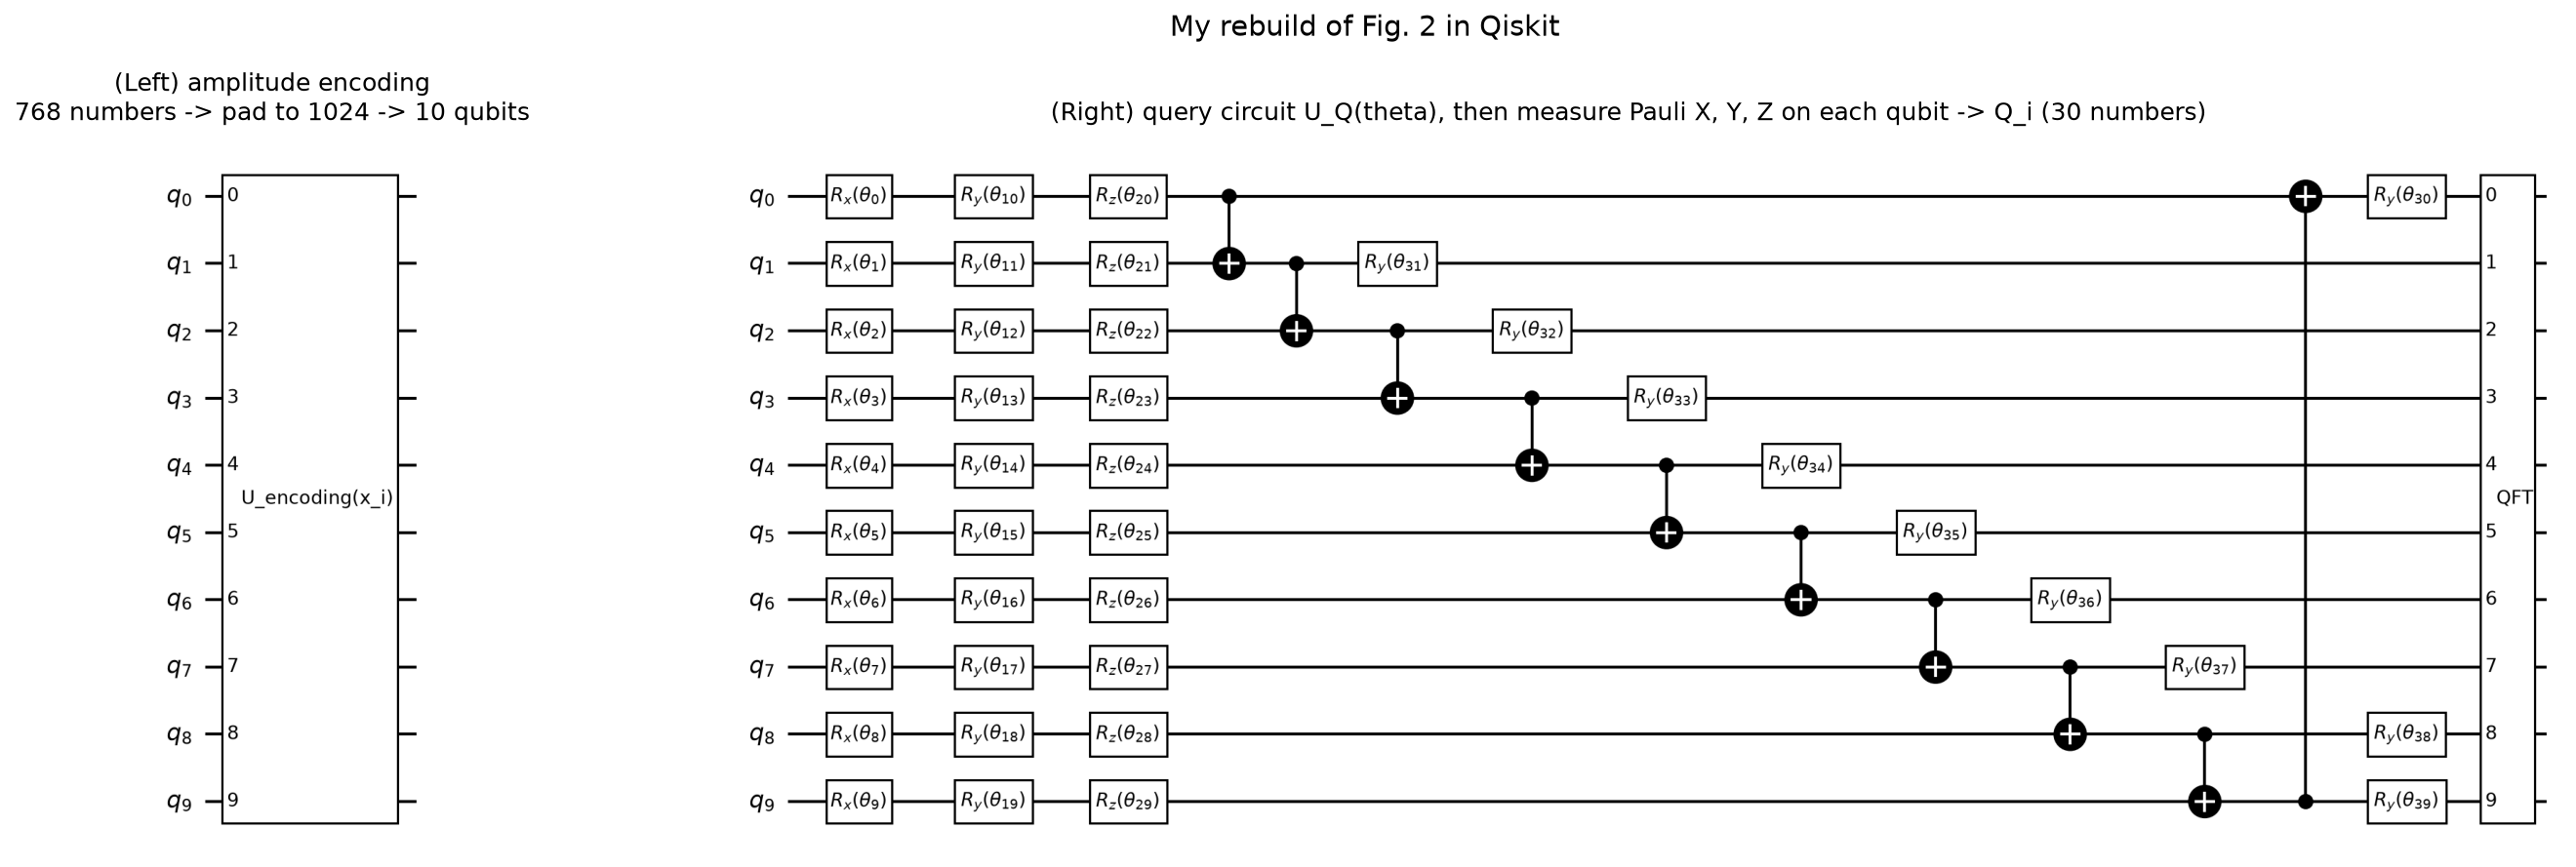

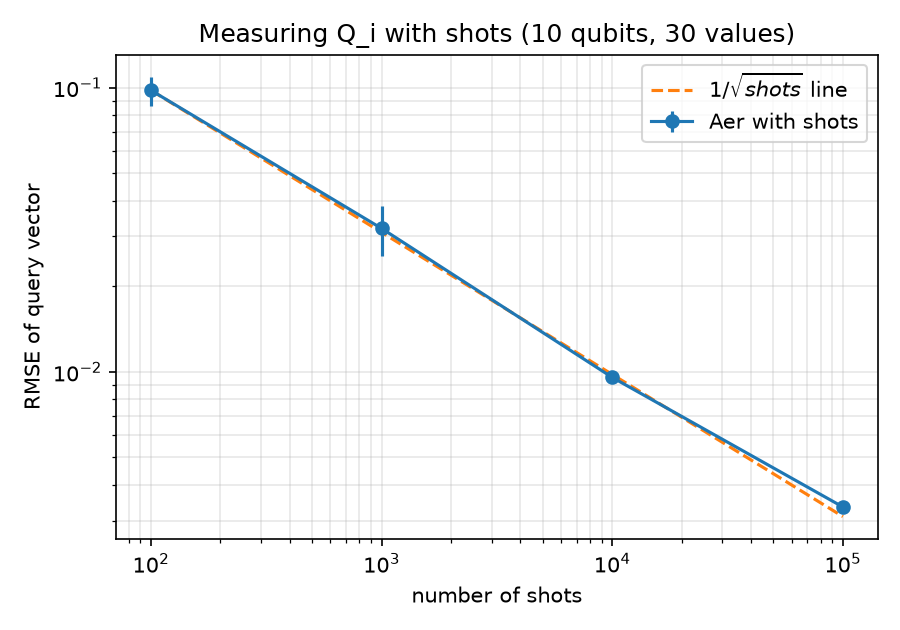

In [3]:
# My attempt to rebuild Figure 2 of the paper
# "Hybrid Quantum-Classical Graph Transformers for Efficient Sentiment Analysis"
# Professor Badawy, Abdel Hameed

import os
import numpy as np
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
from matplotlib.image import imread

from qiskit import QuantumCircuit, transpile
from qiskit.circuit import Gate, ParameterVector
from qiskit.circuit.library import StatePreparation, RXGate, RYGate, RZGate
from qiskit.quantum_info import Statevector, SparsePauliOp
from qiskit_aer import AerSimulator

# QFT: new Qiskit has QFTGate, older versions have QFT
try:
    from qiskit.circuit.library import QFTGate
    def make_qft(n):
        return QFTGate(n)
except ImportError:
    from qiskit.circuit.library import QFT
    def make_qft(n):
        return QFT(n).to_gate()

N = 10            # 768 numbers are padded to 1024 = 2^10, so we need 10 qubits
EMB_DIM = 768     # size of a BERT embedding


# ------------------------------------------------------------------
# part 1: the input vector (pad with zeros to 1024, then normalize)
# ------------------------------------------------------------------

def make_embedding(seed=0):
    rng = np.random.default_rng(seed)
    x = np.zeros(2 ** N)
    x[:EMB_DIM] = rng.normal(size=EMB_DIM)   # random numbers instead of BERT
    return x / np.linalg.norm(x)              # amplitudes must have norm 1


# ------------------------------------------------------------------
# part 2: Figure 2 (left), amplitude encoding
# ------------------------------------------------------------------

def amplitude_encoding(x):
    # StatePreparation puts x into the amplitudes: |psi> = sum_j x_j |j>
    qc = QuantumCircuit(N, name="U_encoding")
    qc.append(StatePreparation(x), range(N))
    return qc


# ------------------------------------------------------------------
# part 3: Figure 2 (right), the circuit U_Q(theta)
# 4 layers x 10 qubits = 40 parameters
# ------------------------------------------------------------------

def build_uq(params, labeled=False):
    # labeled=True is only for the picture (boxes show Rx(theta_0) like the
    # paper). For computing I always use labeled=False.
    qc = QuantumCircuit(N, name="U_Q")

    def rot(axis, idx, q):
        if labeled:
            g = Gate(name=f"r{axis}{idx}", num_qubits=1, params=[],
                     label=rf"$R_{axis}(\theta_{{{idx}}})$")
            qc.append(g, [q])
        else:
            gate = {"x": RXGate, "y": RYGate, "z": RZGate}[axis]
            qc.append(gate(params[idx]), [q])

    for q in range(N):          # Rx(theta_0 ... theta_9)
        rot("x", 0 * N + q, q)
    for q in range(N):          # Ry(theta_10 ... theta_19)
        rot("y", 1 * N + q, q)
    for q in range(N):          # Rz(theta_20 ... theta_29)
        rot("z", 2 * N + q, q)

    for q in range(N):          # ring of CNOTs, the last one is q9 -> q0
        qc.cx(q, (q + 1) % N)

    for q in range(N):          # Ry(theta_30 ... theta_39)
        rot("y", 3 * N + q, q)

    if labeled:                 # QFT on all qubits
        qft = Gate(name="QFT", num_qubits=N, params=[], label="QFT")
    else:
        qft = make_qft(N)
    qc.append(qft, range(N))
    return qc


# ------------------------------------------------------------------
# part 4: draw the figure (left and right side by side)
# ------------------------------------------------------------------

def draw_figure(filename="fig2_rebuild.png"):
    theta = ParameterVector("θ", 4 * N)

    # left part: a plain box named U_encoding(x_i), like the paper
    left = QuantumCircuit(N)
    left.append(Gate(name="U_encoding", num_qubits=N, params=[],
                     label="U_encoding(x_i)"), range(N))

    right = build_uq(theta, labeled=True)

    style = {"name": "bw", "fontsize": 13}
    left.draw("mpl", style=style, filename="_left.png")
    right.draw("mpl", style=style, fold=-1, filename="_right.png")
    plt.close("all")

    fig = plt.figure(figsize=(19, 6))
    gs = fig.add_gridspec(1, 2, width_ratios=[1, 4])
    ax1 = fig.add_subplot(gs[0])
    ax1.imshow(imread("_left.png"))
    ax1.axis("off")
    ax1.set_title("(Left) amplitude encoding\n768 numbers -> pad to 1024 -> 10 qubits")
    ax2 = fig.add_subplot(gs[1])
    ax2.imshow(imread("_right.png"))
    ax2.axis("off")
    ax2.set_title("(Right) query circuit U_Q(theta), then measure Pauli X, Y, Z "
                  "on each qubit -> Q_i (30 numbers)")
    fig.suptitle("My rebuild of Fig. 2 in Qiskit", fontsize=14)
    fig.tight_layout()
    fig.savefig(filename, dpi=150, bbox_inches="tight")
    plt.close(fig)

    for f in ["_left.png", "_right.png"]:   # remove temporary images
        os.remove(f)
    print("Saved figure:", filename)


# ------------------------------------------------------------------
# part 5: run in Aer, exact simulation
# Aer can save the expectation value of an operator directly.
# ------------------------------------------------------------------

PAULIS = ["X", "Y", "Z"]


def exact_query_with_aer(full_circuit):
    sim = AerSimulator(method="statevector")
    qc = full_circuit.copy()
    for q in range(N):
        for p in PAULIS:
            # expectation value of Pauli p on qubit q
            qc.save_expectation_value(SparsePauliOp(p), [q], label=f"{p}{q}")
    tqc = transpile(qc, sim, optimization_level=0)
    data = sim.run(tqc).result().data(0)
    # order: X0, Y0, Z0, X1, Y1, Z1, ...
    return np.array([data[f"{p}{q}"] for q in range(N) for p in PAULIS])


def exact_query_with_statevector(full_circuit):
    # same numbers, but computed with Qiskit's Statevector (no Aer) as a check
    state = Statevector.from_instruction(full_circuit)
    out = []
    for q in range(N):
        for p in PAULIS:
            label = "I" * (N - 1 - q) + p + "I" * q     # rightmost = qubit 0
            out.append(np.real(state.expectation_value(SparsePauliOp(label))))
    return np.array(out)


# ------------------------------------------------------------------
# part 6: run in Aer with shots, like a real quantum computer
# A real device only gives 0/1 results in the Z basis, so:
#   to measure X -> apply H before measuring
#   to measure Y -> apply Sdg then H before measuring
#   to measure Z -> measure directly
# 3 circuits give all 30 numbers (each circuit measures all qubits)
# ------------------------------------------------------------------

def make_measurement_circuits(full_circuit):
    circuits = {}
    for p in PAULIS:
        c = full_circuit.copy()
        if p == "X":
            c.h(range(N))
        elif p == "Y":
            c.sdg(range(N))
            c.h(range(N))
        c.measure_all()
        circuits[p] = c
    return circuits


def expectations_from_counts(counts, shots):
    # <P_q> = (number of 0 - number of 1) / shots for qubit q
    e = np.zeros(N)
    for bitstring, c in counts.items():
        bits = bitstring[::-1]          # now bits[q] is the result of qubit q
        for q in range(N):
            e[q] += c if bits[q] == "0" else -c
    return e / shots


def shot_query(transpiled, sim, shots, seed):
    e = {}
    for p in PAULIS:
        counts = sim.run(transpiled[p], shots=shots, seed_simulator=seed).result().get_counts()
        e[p] = expectations_from_counts(counts, shots)
    return np.array([e[p][q] for q in range(N) for p in PAULIS])


def shot_error_experiment(full_circuit, q_exact, filename="aer_shot_error.png"):
    sim = AerSimulator()
    circuits = make_measurement_circuits(full_circuit)
    # transpile only one time (the encoding part is big)
    transpiled = {p: transpile(c, sim, optimization_level=0) for p, c in circuits.items()}

    shots_list = [100, 1000, 10000, 100000]
    repeats = 5
    rmse_mean, rmse_std = [], []

    print("\nShot-based measurement vs exact Aer (RMSE over the 30 values):")
    for shots in shots_list:
        errs = []
        for r in range(repeats):
            q_shot = shot_query(transpiled, sim, shots, seed=100 + r)
            errs.append(np.sqrt(np.mean((q_shot - q_exact) ** 2)))
        rmse_mean.append(np.mean(errs))
        rmse_std.append(np.std(errs))
        print(f"  shots = {shots:>6d}   RMSE = {np.mean(errs):.4f} +- {np.std(errs):.4f}")

    # plot, with a 1/sqrt(shots) line to compare
    shots_arr = np.array(shots_list)
    ref = rmse_mean[0] * np.sqrt(shots_arr[0]) / np.sqrt(shots_arr)
    plt.figure(figsize=(6, 4.2))
    plt.errorbar(shots_arr, rmse_mean, yerr=rmse_std, marker="o", label="Aer with shots")
    plt.plot(shots_arr, ref, "--", label=r"$1/\sqrt{shots}$ line")
    plt.xscale("log")
    plt.yscale("log")
    plt.xlabel("number of shots")
    plt.ylabel("RMSE of query vector")
    plt.title("Measuring Q_i with shots (10 qubits, 30 values)")
    plt.grid(alpha=0.3, which="both")
    plt.legend()
    plt.tight_layout()
    plt.savefig(filename, dpi=150)
    plt.close()
    print("Saved figure:", filename)


# ------------------------------------------------------------------
# main
# ------------------------------------------------------------------

def main():
    # 1) draw Figure 2
    draw_figure()

    # 2) build the circuits: U_encoding(x), U_Q(theta), U_K(phi)
    x = make_embedding(seed=0)
    enc = amplitude_encoding(x)

    rng = np.random.default_rng(1)
    theta = rng.normal(0, 1.0, 4 * N)     # parameters of U_Q (random, no training)
    phi = rng.normal(0, 1.0, 4 * N)       # parameters of U_K

    full_q = enc.compose(build_uq(theta))    # U_Q * U_encoding
    full_k = enc.compose(build_uq(phi))      # U_K * U_encoding

    print("\nNumber of qubits           :", N)
    print("Trainable parameters in U_Q:", len(theta), "(4 x n)")
    print("Trainable parameters in U_K:", len(phi), "(4 x n)")
    print("Total quantum parameters   :", len(theta) + len(phi), "(the paper says 80)")

    # 3) exact simulation in Aer
    Q = exact_query_with_aer(full_q)
    K = exact_query_with_aer(full_k)
    print("\nQuery vector length:", len(Q), "(3 x n = 30)")
    print("First 6 values of Q (Aer):", np.round(Q[:6], 4))

    # 4) check against Qiskit's Statevector
    Q_check = exact_query_with_statevector(full_q)
    print("Max difference Aer vs Statevector:", f"{np.max(np.abs(Q - Q_check)):.2e}")

    # 5) attention score of one token with itself, Eq. (9) of the paper
    score = float(Q @ K) / np.sqrt(3 * N)
    print("Scaled dot product Q.K / sqrt(30) =", round(score, 4))

    # 6) shots, like a real quantum computer
    shot_error_experiment(full_q, Q)


if __name__ == "__main__":
    main()
    from IPython.display import display
    from PIL import Image

    display(Image.open("fig2_rebuild.png"))
    display(Image.open("aer_shot_error.png"))